# Análisis de las series de tiempo a utilizar

A continuación se llevarán a cabo los distintos pasos para analizar las series de tiempo asociadas al trabajo de título.

# Importaciones





Se inicia realizando las importaciones necesarias

In [ ]:
pip install adtk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import seaborn as sns
from google.colab import drive
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats

# Se lee la base de datos

In [2]:
#drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Tesis/Data/consumption.csv')

En una primera etapa, se busca comprender el dataframe, en específico sus características. Para lograr esto se imprime la forma de la base de datos (filas, columnas), el nombre de las columnas, y a modo de prueba, se imprimen las primeras  5 observaciones que la conforman.

In [3]:
#Se imprime la forma
print(df.shape)

#Se imprime el nombre de las columnas
print(df.columns)

#Se imprimen las primeras 5 observaciones
print(df.head())


(52416, 9)
Index(['DateTime', 'Temperature', 'Humidity', 'Wind Speed',
       'general diffuse flows', 'diffuse flows', 'Zone 1 Power Consumption',
       'Zone 2  Power Consumption', 'Zone 3  Power Consumption'],
      dtype='object')
        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   
3  

Desde este punto, se puede concluir que la base de datos cuenta con 52.416 filas y 9 columnas (8 sin contar la variable datetime).


---



Los nombres de las columnas son muy largos.



---

Se cambiará el formato de date time, y esta columna se pasará a index




Siendo una serie de tiempo, se incluirá la fecha y hora de la observación como el index del dataframe

In [4]:
# Se cambia columna
df['date'] = pd.to_datetime(df['DateTime'], format='%m/%d/%Y %H:%M')

# Se establece la columna date como index
df.set_index('date', inplace=True)

# Se elimina la columna original
df.drop(['DateTime'], axis=1, inplace=True)

# Se muestra el dataframe resultante
print(df)

                     Temperature  Humidity  Wind Speed  general diffuse flows  \
date                                                                            
2017-01-01 00:00:00        6.559      73.8       0.083                  0.051   
2017-01-01 00:10:00        6.414      74.5       0.083                  0.070   
2017-01-01 00:20:00        6.313      74.5       0.080                  0.062   
2017-01-01 00:30:00        6.121      75.0       0.083                  0.091   
2017-01-01 00:40:00        5.921      75.7       0.081                  0.048   
...                          ...       ...         ...                    ...   
2017-12-30 23:10:00        7.010      72.4       0.080                  0.040   
2017-12-30 23:20:00        6.947      72.6       0.082                  0.051   
2017-12-30 23:30:00        6.900      72.8       0.086                  0.084   
2017-12-30 23:40:00        6.758      73.0       0.080                  0.066   
2017-12-30 23:50:00        6

A modo de que sean más comprensibles y sigan un estándar predeterminado (abreviaciones en minúsculas), se modifica el nombre de las columnas

In [5]:
names = ['temp', 'hum', 'wnd_spd', 'gen_dif_flw', 'dif_flw', 'zone1', 'zone2', 'zone3']
df.columns = names
print(df)

                      temp   hum  wnd_spd  gen_dif_flw  dif_flw        zone1  \
date                                                                           
2017-01-01 00:00:00  6.559  73.8    0.083        0.051    0.119  34055.69620   
2017-01-01 00:10:00  6.414  74.5    0.083        0.070    0.085  29814.68354   
2017-01-01 00:20:00  6.313  74.5    0.080        0.062    0.100  29128.10127   
2017-01-01 00:30:00  6.121  75.0    0.083        0.091    0.096  28228.86076   
2017-01-01 00:40:00  5.921  75.7    0.081        0.048    0.085  27335.69620   
...                    ...   ...      ...          ...      ...          ...   
2017-12-30 23:10:00  7.010  72.4    0.080        0.040    0.096  31160.45627   
2017-12-30 23:20:00  6.947  72.6    0.082        0.051    0.093  30430.41825   
2017-12-30 23:30:00  6.900  72.8    0.086        0.084    0.074  29590.87452   
2017-12-30 23:40:00  6.758  73.0    0.080        0.066    0.089  28958.17490   
2017-12-30 23:50:00  6.580  74.1    0.08

# Análisis EDA

## Discretización y numeración

Se revisa el tipo de datos de las variables

In [ ]:
#Se imprime el tipo de dato
print(df.dtypes)
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe es un tipo de dato: ",df.index.dtype)

temp           float64
hum            float64
wnd_spd        float64
gen_dif_flw    float64
dif_flw        float64
zone1          float64
zone2          float64
zone3          float64
dtype: object
El index del dataframe es un tipo de dato:  datetime64[ns]


Todos los datos son numéricos

## Aumento de dimensionalidad

A partir de lo explicado en la literatura, se crea una variable exógena extra, la hora de la observación. Por conveniencia, a pesar de que este valor se ecuentra contenido en el index del dataset, se decide aislarlo en su propia columna.

In [ ]:
df["hour"] = df.index.hour

df.head(10)


,temp,hum,wnd_spd,gen_dif_flw,dif_flw,zone1,zone2,zone3,hour
date,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0
2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048,0
2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024,1
2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711,1
2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217,1


## Reconocimiento

Se procede a analizar diferentes métricas estadísticas de la base de datos

In [ ]:
df.describe()

,temp,hum,wnd_spd,gen_dif_flw,dif_flw,zone1,zone2,zone3,hour
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218,11.500000
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099,6.922253
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070,0.000000
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630,5.750000
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470,11.500000
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420,17.250000
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360,23.000000


De la tabla anterior se puede apreciar que:



1.   Todas las columnas tienen la misma cantidad de datos, que es igual a la cantidad de observaciones (datos completos)
2.   Los valores de mean y std entre las diferentes columnas cambian considerablemente, dando cuenta así de la diferentes escalas que se manejan dentro del dataset original.
1.   Todas las varaiables pareciesen ser datos numéricos contínuos, con valores positivos distintos de 0.
1.   gen_dif_flw y dif_flw en 75% tienen valores muy alejados del 50%, mientras que entre el 75% y el máximo existe una diferencia considerable no solo para estas variables, sino que también para zone1, zone2 y zone3. También, las primeras 2 columnas mencionadas tienen un valor del 50% muy por debajo del valor de la media.





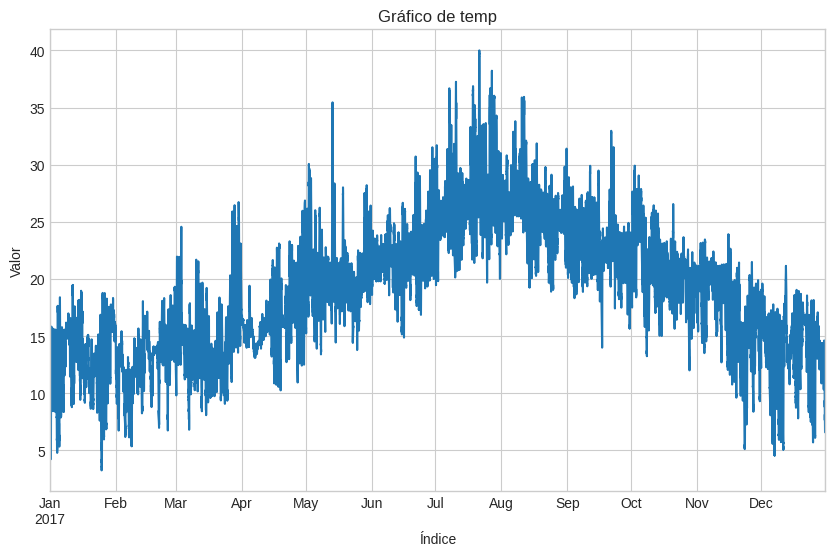

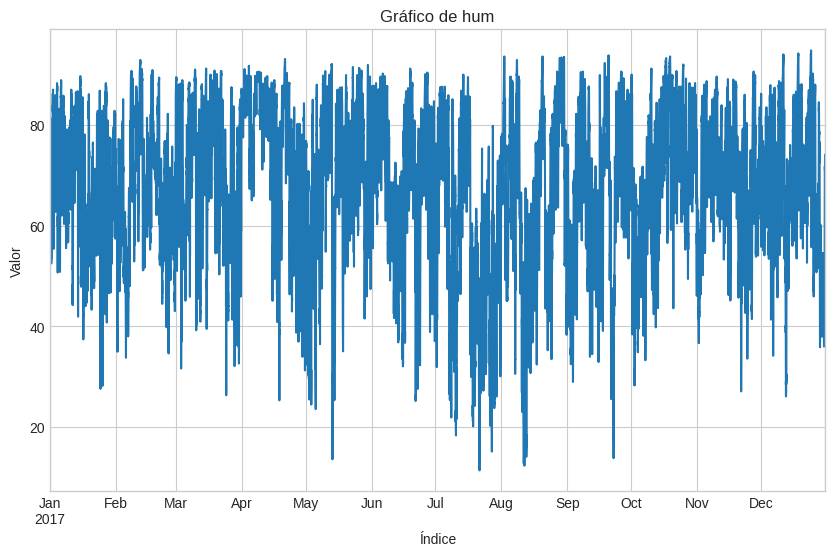

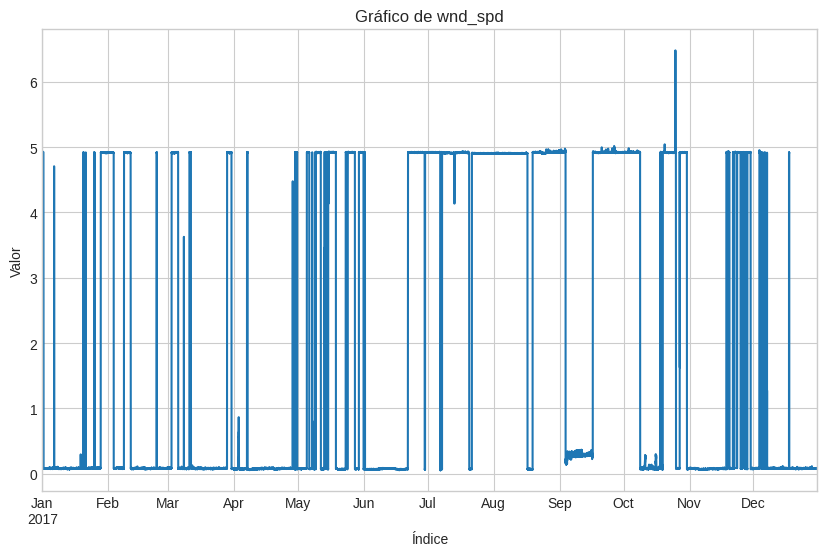

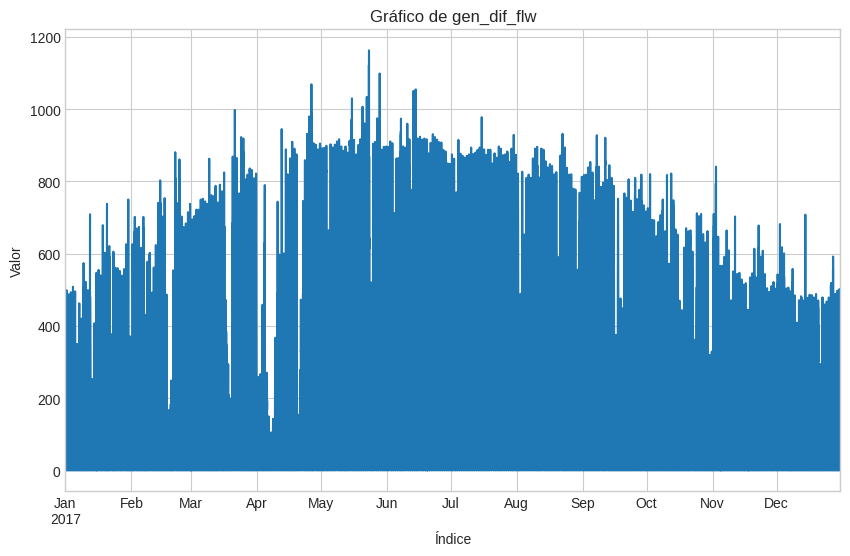

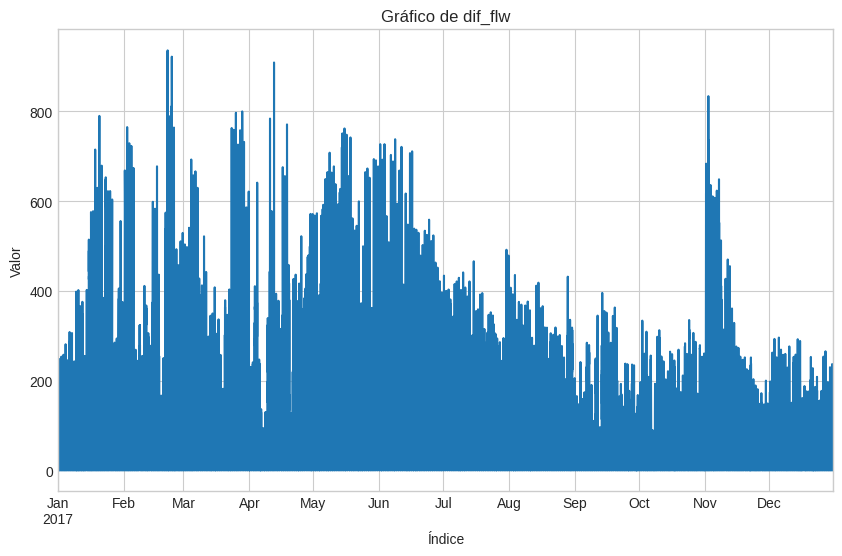

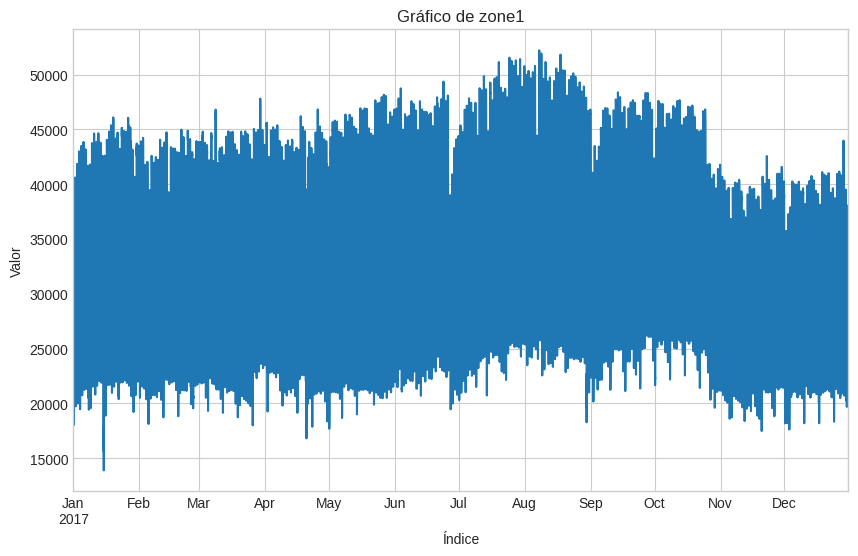

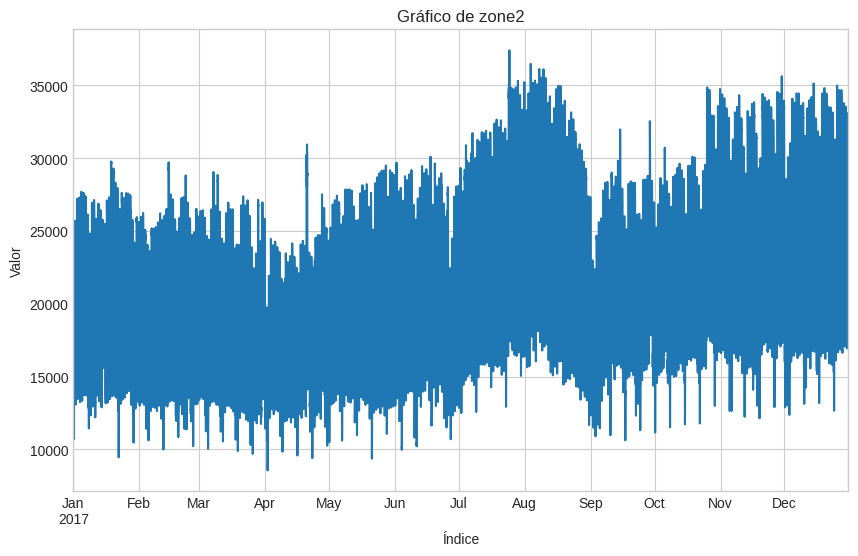

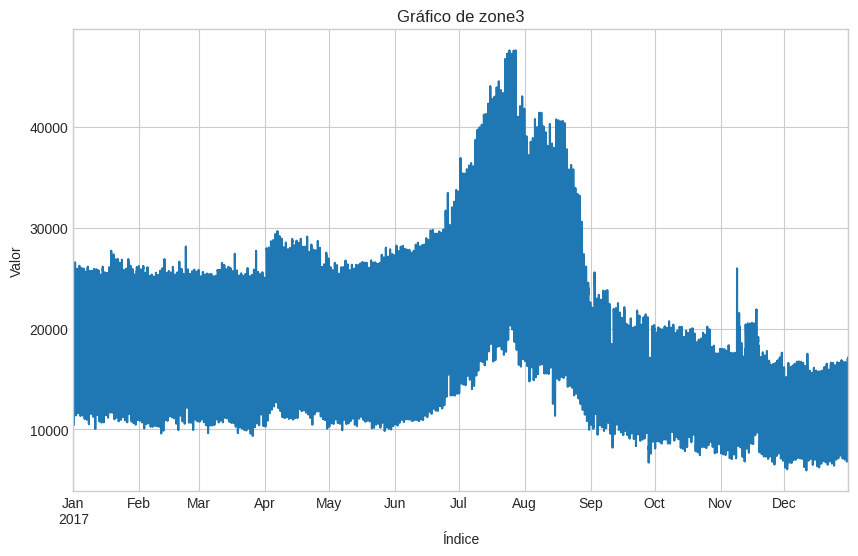

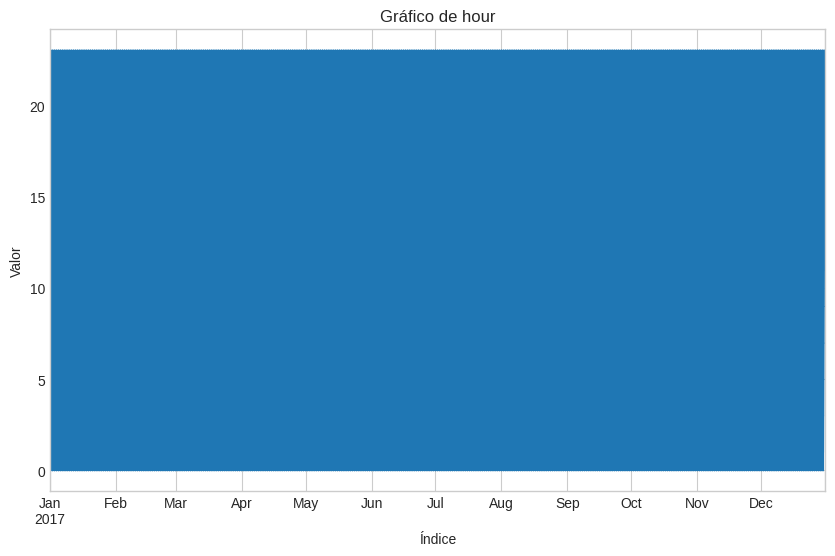

In [ ]:
# Iteramos sobre cada columna y trazamos un gráfico para cada una
for col in df.columns:
    plt.figure(figsize=(10, 6))  # Tamaño del gráfico
    df[col].plot()
    plt.title('Gráfico de {}'.format(col))
    plt.xlabel('Índice')  
    plt.ylabel('Valor')   
    plt.show()

Al imprimir los histogramas asociados a cada variable es posible ver que las variables temp y zone2 pareciesen tener distribuciones cercanas a la normal, zone1 de igual manera pareciese ser cercana a la normal pero con un rango cuya frecuencia se excede a la izquierda, llevando a que se asemeje a una distribución bimodal. Zone3 y hum pareciesen ser distribuciones "skewed", hacia la izquierda y hacia la derecha respectivamente. La mayoría de valores de gen_dif_flw y dif_flw están acumulados en la parte izquierda del gráfico. De cierta forma, este comportamiento se podría considerar como normal, puesto que naturalmente existe un límite inferior en cuanto a estas 2 variables, lo que impide que dichos valores puedan llegar a ser menores que 0, demostrando una forma normal. De todas formas, estos histogramas en particular demuestran que existen valores bastante alejados, lo que podría significar la existencia de valores atípicos u "outliers". Por último, la variable wnd_spd posee la distribución que más sobresale, teniendo únicamente 2 rangos relevantes de valores.

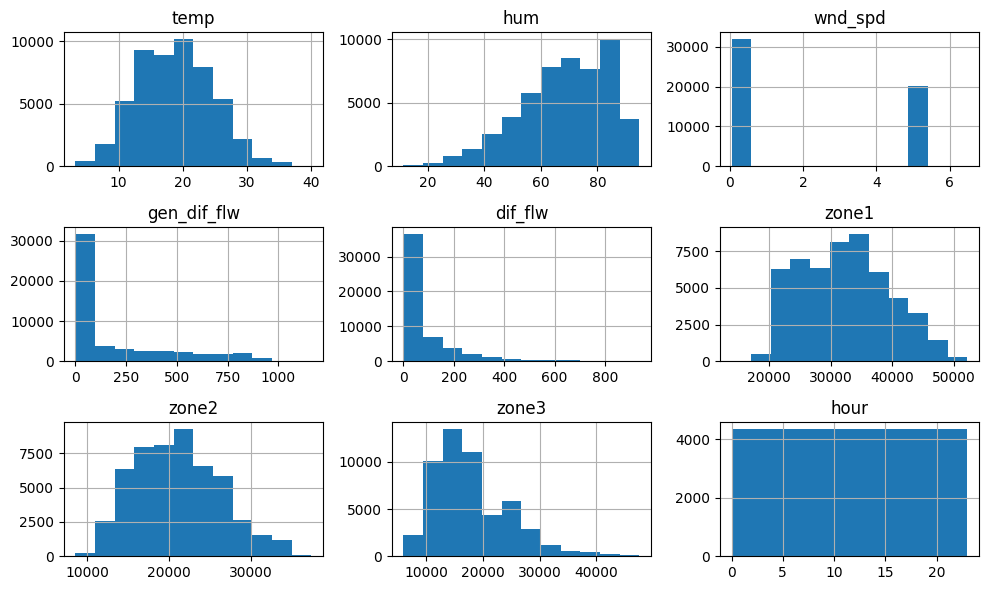

In [ ]:
# Trazar un histograma para cada variable en el DataFrame
df.hist(figsize=(10, 6), bins=12)

# Mostrar los histogramas
plt.tight_layout()
plt.show()

In [ ]:
sns.pairplot(df)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df_corr= df.corr()

<Axes: >

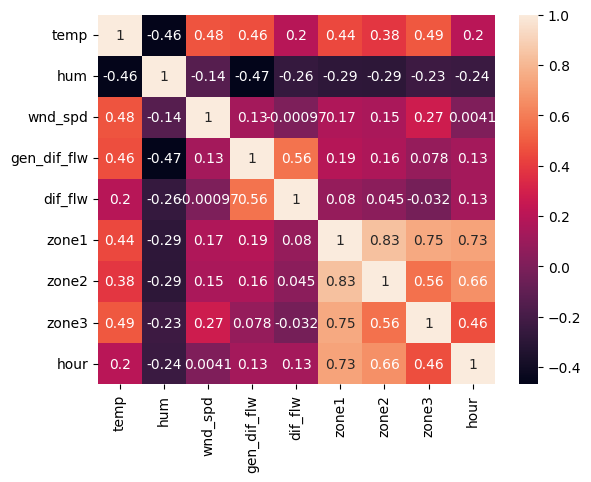

In [ ]:
sns.heatmap(df_corr, annot=True)

<Axes: >

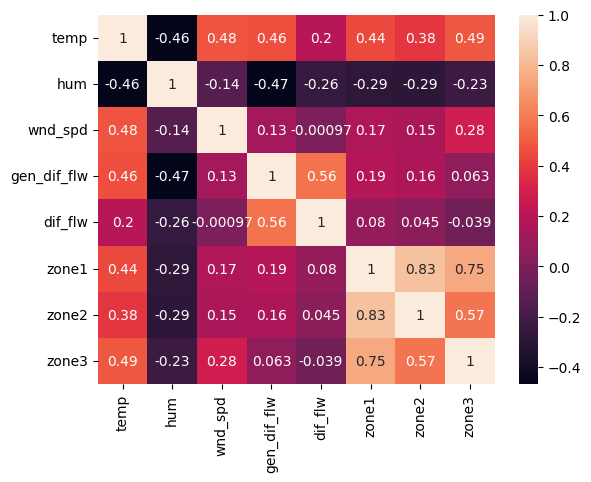

In [6]:
df_corr= df.corr()
sns.heatmap(df_corr, annot=True)

## Valores faltantes

Se revisa la presencia de valores NaN

In [ ]:
df.isna().sum()


,0
temp,0
hum,0
wnd_spd,0
gen_dif_flw,0
dif_flw,0
zone1,0
zone2,0
zone3,0
hour,0


El dataset no posee valores faltantes

## Valores anómalos

Se procede a analizar la existencia de datos duplicados en el dataset. En total hay 0 valores duplicados


In [ ]:
print("La cantidad de duplicados son: ",len(df[df.duplicated()]))

La cantidad de duplicados son:  0


Mediante gráficos boxplot, se revisa la existencia de outliers en cada una de las variables. De acuerdo a los gráficos, todas las variables tienen outliers, a excepción de zone1 y wnd_spd.

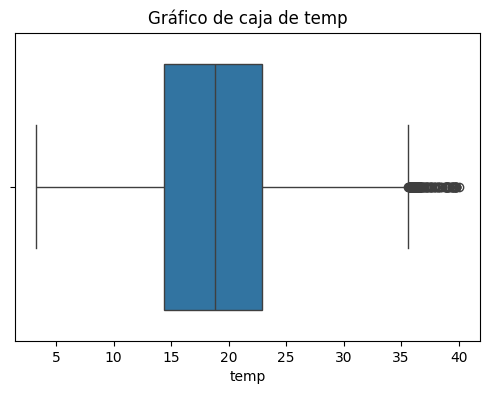

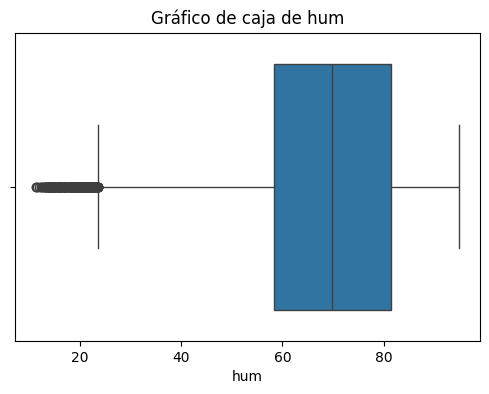

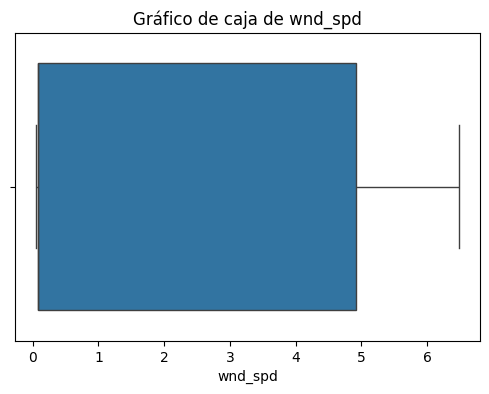

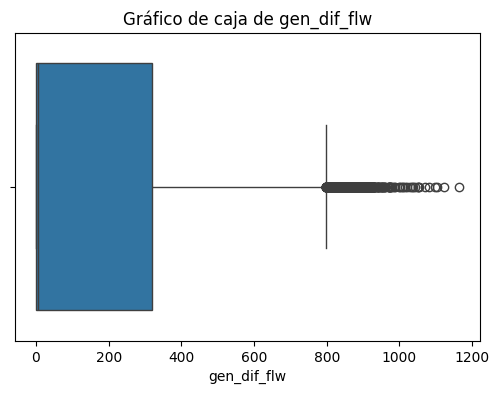

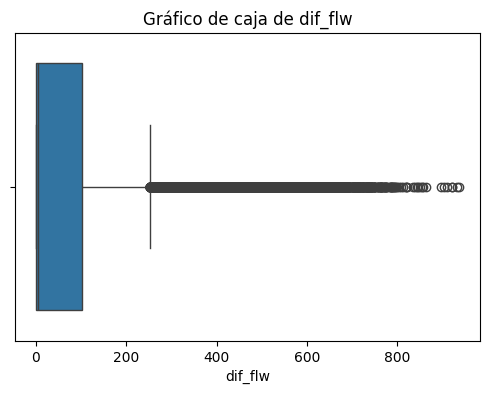

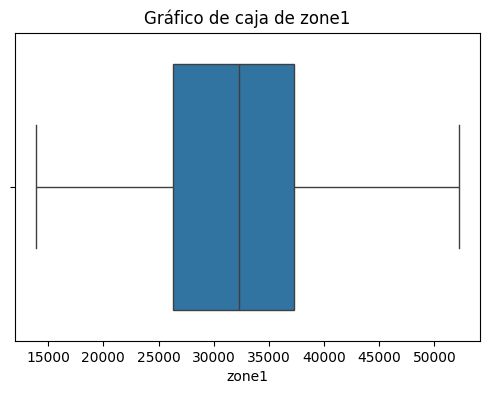

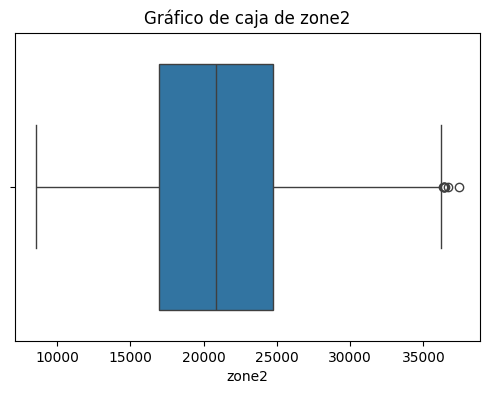

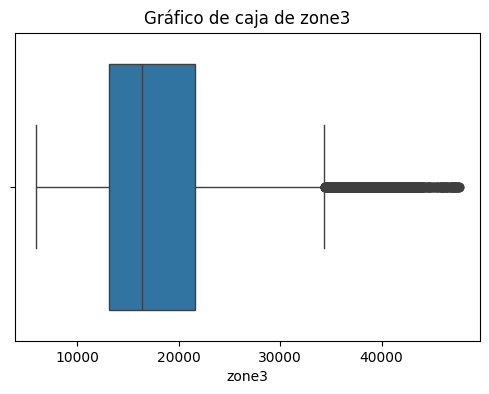

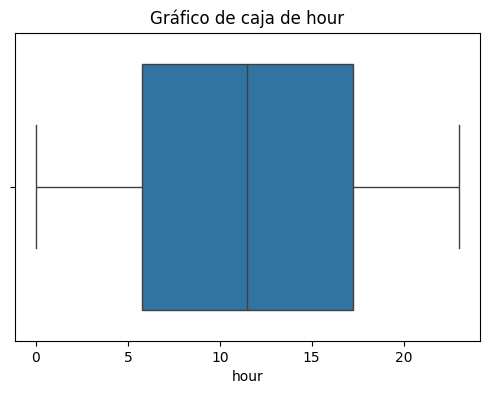

In [ ]:
for col in df.columns:
    plt.figure(figsize=(6, 4))  # Tamaño del gráfico individual
    sns.boxplot(x=df[col])
    plt.title('Gráfico de caja de {}'.format(col))
    plt.xlabel(col)
    plt.show()

Se define función que suma la cantidad de outliers de una variable de acuerdo al método IQR con 1,5.

In [ ]:
def sumarOutliers(nombre):
  Q1 = np.percentile(df[nombre], 25)
  Q3 = np.percentile(df[nombre], 75)

  # Calcular el rango intercuartil
  IQR = Q3 - Q1
  # Calcular el límite superior
  LS = Q3 + 1.5 * IQR
  # Calcular el límite inferior
  LI = Q1 - 1.5 * IQR
  # Contar la cantidad de puntos que están por encima de LS y por debajo de LI
  cont1 = np.sum(df[nombre] > LS)
  cont2 = np.sum(df[nombre] < LI)

  return (cont1 + cont2)


In [ ]:
for columna in df:
  total = sumarOutliers(columna)
  print("Hay ", total, "outliers para la variable ", columna)
  porcentaje = (total / df.shape[0])*100
  print("El porcentaje de dicho valor es: ",porcentaje)
  print("")

Hay  142 outliers para la variable  temp
El porcentaje de dicho valor es:  0.2709096459096459

Hay  291 outliers para la variable  hum
El porcentaje de dicho valor es:  0.5551739926739927

Hay  0 outliers para la variable  wnd_spd
El porcentaje de dicho valor es:  0.0

Hay  2315 outliers para la variable  gen_dif_flw
El porcentaje de dicho valor es:  4.416590354090355

Hay  4571 outliers para la variable  dif_flw
El porcentaje de dicho valor es:  8.720619658119658

Hay  0 outliers para la variable  zone1
El porcentaje de dicho valor es:  0.0

Hay  7 outliers para la variable  zone2
El porcentaje de dicho valor es:  0.013354700854700856

Hay  1191 outliers para la variable  zone3
El porcentaje de dicho valor es:  2.2722069597069594

Hay  0 outliers para la variable  hour
El porcentaje de dicho valor es:  0.0



Se instala librería para visualizar los resultados del método IQR. De los gráficos es posible ver que, si bien existen valores atípicos, la distribución de estos a simple vista no pareciese alejarse de la normalidad asociadas a dichas variables. A continuación se listan las diferentes variables con valores atípicos y las conclusiones a las que se puede llegar.




*   Temperatura: Se marcan como valores atípicos aquellos entre los 35°C y los 40°C. Eliminar o cambiar estos valores atípicos podría limitar el análisis, puesto que, viendo las características de las observaciones, no pareciese distar de la realidad. En específico, los valores se registran en el mes de julio y agosto, verano en la ciudad de Tetouan e históricamente los meses con temperaturas promedio mayores (https://www.climatestotravel.com/climate/morocco/tetouan). De igual manera el alcanzar temperaturas cercanas a los 40°C no es raro en la región, ya que, hasta ese momento el record histórico fueron 42°C ocurridos el año 1976, siendo superada en 2021 con 42.2°C en agosto (https://www.middleeastmonitor.com/20210818-morocco-records-highest-temperature-since-1925/). Es por lo anterior que se concluye que estos valores atípicos no constituyen anomalías y por ende no es necesario que sean tratados.

*   Humedad: Históricamente, la humedad relativa más baja se alcanza, en el contexto de la ciudad de Tetouan, en el mes de julio (65%) (https://wanderlog.com/weather/79513/7/tetouan-weather-in-july). Los meses cercanos también suelen tener una humedad relativa baja en comparación al resto del año. Es por esto que no es raro que los valores atípicos se presenten en estas fechas. Por otro lado, haciendo una comparación con otro sistema que mide las condiciones climáticas en Tetouan (https://www.weatheronline.in/weather/maps/city), para el año 2017 se obtuvieron resultados bastante similares a los presentes en el dataset. Es por lo anterior que se decide mantener los datos tal como están.  

*   Genaral Diffuse Flow y Diffuse Flow: En la documentación oficial del dataset no se hace referencia a que se refieren por estos términos, más allá de que se obtuvieron bajo las mismas condiciones que el resto de variables climatológicas. La gráfica no ayuda a dislumbrar a que se refieren tampoco. De acuerdo a un proyecto en github (https://github.com/SoukainaBoufousse/ML_predict-the-power-consumption-in-10-minute-windows-of-Tetouan-city) que trabaja con el dataset, describen a estas variables como: "The general diffuse flows in the city, which may include air or water flows" para General Diffuse Flow y "This attribute represents a specific type of diffuse flow in the city" para Diffuse Flow. Esta información tampoco permite llegar a alguna conclusión. Por el momento se decide dejar estas variables tal como están ya que, si se decide eliminar los outliers, a simple vista se estaría perdiendo mucha información, y de igual manera si se deján, algunos de estos pueden implicar comportamientos anómalos que debieron haber sido eliminados. De todas formas, es muy probable que más adelante se eliminen estas variables, ya que, de acuerdo a la documentación original, estas variables no fueron lo suficientemente relevantes como para ser consideradas en el análisis. Se estudiará esto posteriormente.

*   Zone2 y Zone3: Los comportamientos vistos en estas variables se considera como normal, tomando como base la documnetación oficial, en donde se explica que en los meses de verano el consumo medido aumenta (lo que explicaría los datos atípicos) mientras que en Noviembre y Diciembre el consumo en Zone1 y Zone3 disminuye, y el consumo en Zone2 aumenta.



In [ ]:
from adtk.visualization import plot as adtkPlot
from adtk.detector import InterQuartileRangeAD

iqr_detector = InterQuartileRangeAD(c=1.5)

for columna in df:
  anomalies = iqr_detector.fit_detect(df[columna])
  adtkPlot(df[columna], anomaly=anomalies, anomaly_color="red", anomaly_tag="marker")


Output hidden; open in https://colab.research.google.com to view.

Se prueban otros métodos para detectar outliers, pero sin conocer una aprocximación del parámetro contaminación, aplicando la cantidad de outliers detectados por el método IQR se llegan a los mismos resultados (random forest) o resultados que no son satisfactorios (LOF).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

for name in df:

  outliers_fraction = sumarOutliers(name) / (df.shape[0])
  if outliers_fraction > 0:
    # IsFo
    model1 =  IsolationForest(contamination=outliers_fraction)
    model1.fit(df[name].values.reshape(-1, 1))
    anomaly1 = model1.fit_predict(df[name].values.reshape(-1, 1))

    # LOF
    model2 =  LocalOutlierFactor(contamination=outliers_fraction)
    model2.fit(df[name].values.reshape(-1, 1))
    anomaly2 = model2.fit_predict(df[name].values.reshape(-1, 1))


    anomaly1 = pd.DataFrame(anomaly1)
    anomaly1.index = df.index
    anomaly2 = pd.DataFrame(anomaly2)
    anomaly2.index = df.index
    
    anomaly1 = anomaly1.replace(1, 0)
    anomaly1 = anomaly1.replace(-1, 1)
    anomaly2 = anomaly2.replace(1, 0)
    anomaly2 = anomaly2.replace(-1, 1)

    adtkPlot(df[name], anomaly=anomaly1, anomaly_color="red", anomaly_tag="marker")
    plt.title('Isolation Forest, variable: {}'.format(name))

    adtkPlot(df[name], anomaly=anomaly2, anomaly_color="red", anomaly_tag="marker")
    plt.title('Local Outlier Factor, variable: {}'.format(name))

Output hidden; open in https://colab.research.google.com to view.

## Normalización



A continuación se aplica normalización Z-score sobre los datos. Esto se realiza para analizar las variables, no para utilizar los datos en los modelos de aprendizaje profundo.

In [ ]:
def normalizar(data, name):
  columna = (data[name] - data[name].mean()) / data[name].std()
  return columna

In [ ]:
dfNorm = pd.DataFrame()

for name in df:
  dfNorm[name] = normalizar(df, name)



In [ ]:
dfNorm.describe()

,temp,hum,wnd_spd,gen_dif_flw,dif_flw,zone1,zone2,zone3,hour
count,5.241600e+04,5.241600e+04,52416.000000,5.241600e+04,5.241600e+04,5.241600e+04,5.241600e+04,5.241600e+04,52416.000000
mean,2.255691e-16,4.961436e-16,0.000000,-6.073015e-17,-4.771655e-17,-3.470294e-17,1.041088e-16,-1.735147e-17,0.000000
std,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
min,-2.676139e+00,-3.660142e+00,-0.812942,-6.909680e-01,-6.039485e-01,-2.587352e+00,-2.399790e+00,-1.797030e+00,-1.661309
25%,-7.566060e-01,-6.397920e-01,-0.801021,-6.907487e-01,-6.030549e-01,-8.462589e-01,-7.808843e-01,-7.106557e-01,-0.830654
50%,-5.162770e-03,1.029171e-01,-0.797616,-6.719382e-01,-5.681626e-01,-1.108611e-02,-4.216901e-02,-2.144750e-01,0.000000
75%,7.015722e-01,8.449831e-01,1.258274,5.177870e-01,2.090957e-01,6.961649e-01,7.058027e-01,5.721232e-01,0.830654
max,3.645441e+00,1.706654e+00,1.925831,3.707639e+00,6.931530e+00,2.785113e+00,3.146488e+00,4.494439e+00,1.661309


## Reducción de dimensionalidad

### Usando Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)


X = dfNorm.drop('zone1', axis=1)  # Elimina la columna 'zone1'
y = dfNorm['zone1']  # Variable objetivo


# Entrenar un modelo de Random Forest
modelRF = RandomForestRegressor()
modelRF.fit(X, y)


feature_importance = pd.DataFrame(modelRF.feature_importances_, index=X.columns)
print(feature_importance)


                    0
temp         0.028373
hum          0.008834
wnd_spd      0.008605
gen_dif_flw  0.019578
dif_flw      0.007120
zone2        0.297737
zone3        0.172433
hour         0.457321


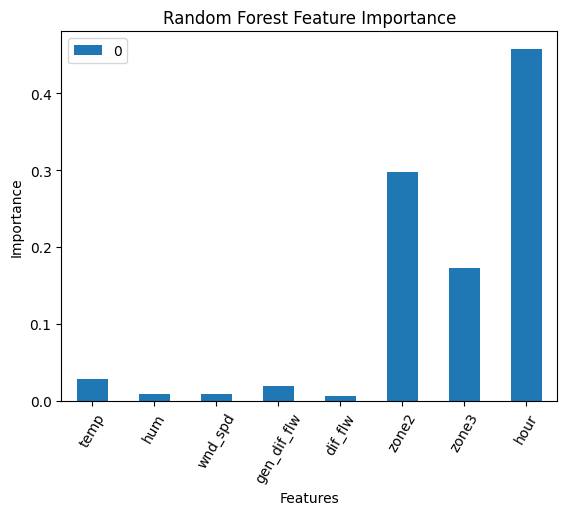

In [ ]:
feature_importance.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=60)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
plt.show()


### Usando Mutual Information

In [ ]:
# Divide los datos en características (X) y la variable objetivo (y)
x = dfNorm.drop('zone1', axis=1)  # Elimina la columna 'zone1'
y = dfNorm['zone1']  # Variable objetivo

In [ ]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
np.random.seed(42)


fs_num = SelectKBest(score_func=mutual_info_regression, k='all')


fs_num.fit(x, y)


feature_importance = pd.DataFrame({'Feature': fs_num.get_feature_names_out().tolist(),
                      'Score': fs_num.scores_.tolist()})

feature_importance = feature_importance.sort_values(by='Score', ascending=False)

print(feature_importance)


       Feature     Score
5        zone2  0.899729
7         hour  0.774809
6        zone3  0.644975
3  gen_dif_flw  0.307052
0         temp  0.249423
4      dif_flw  0.249005
1          hum  0.122054
2      wnd_spd  0.093445


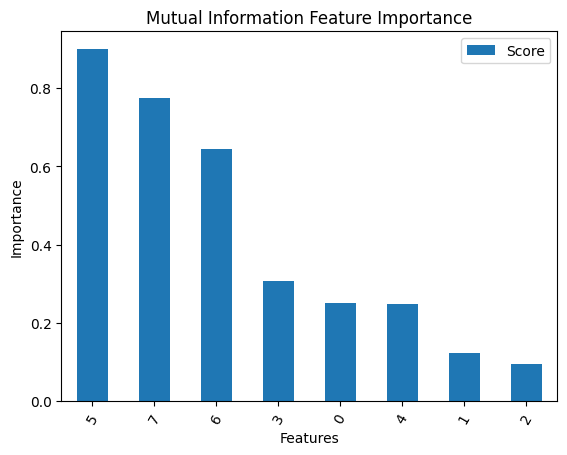

In [ ]:
feature_importance.plot(kind='bar')
plt.title('Mutual Information Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=60)
#plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
plt.show()

Es así como se puede ver que aquellas varaibles más relevantes son hour, zone2 y zone3. Sin embargo, se decide incluir además dentro del análisis la variable temp, puesto que en Random Forest es la cuarta variable más importante, en el análisis original se llega a que es la variable climatológica más relevante, y porque para mutual information está en un rango similar al de las cuartas variavles más importantes.

In [ ]:
final = dfNorm.drop(['gen_dif_flw', 'hum', 'wnd_spd', 'dif_flw'], axis=1)

In [ ]:
final.to_csv('/content/drive/MyDrive/Tesis/Data/consumptionFinal2.csv')

In [ ]:
originalFinal = df.drop(['gen_dif_flw', 'hum', 'wnd_spd', 'dif_flw'], axis=1)
originalFinal.to_csv('/content/drive/MyDrive/Tesis/Data/SNconsumptionFinal.csv')

# Se crean los conjuntos de datos a analizar


## Cálculo de lags óptimos a considerar

Información mutua para temp: [0.24965643332877008, 0.24906733998851305, 0.2523413782590591, 0.24443789709598907, 0.24215717964013184, 0.2417182977284016, 0.23815685900351102, 0.2403179235317774, 0.2390626276284209, 0.23851508774329933, 0.2373792554991656, 0.235902184805016, 0.2411289237944807, 0.24065389171392315, 0.24001008668215285, 0.23472153779723381, 0.23539153961824244, 0.24257038224543948, 0.23459905359606914, 0.23632629660271487, 0.23465454736671454, 0.23809474831043165, 0.2332161759503899, 0.23524306745928847]


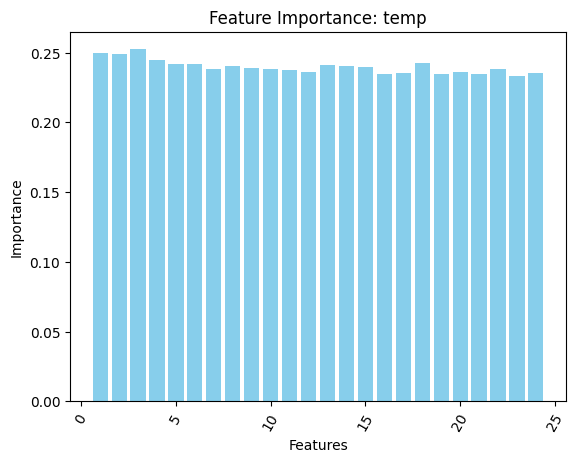

Información mutua para zone1: [2.5633535105188905, 1.9624667929322408, 1.6251184687544722, 1.3965817937647822, 1.222872276126707, 1.0771875942750997, 0.9574788592646719, 0.861705353708353, 0.7787525557404731, 0.7009268778676887, 0.6451573798052745, 0.5866726631351327, 0.5440552773113083, 0.5060455283564842, 0.4729404170761553, 0.43659732523405115, 0.4093242696445918, 0.3870900148934231, 0.3621190122697957, 0.339872372885492, 0.3279897991793659, 0.31005410721600146, 0.3042007073915256, 0.2956798104440672]


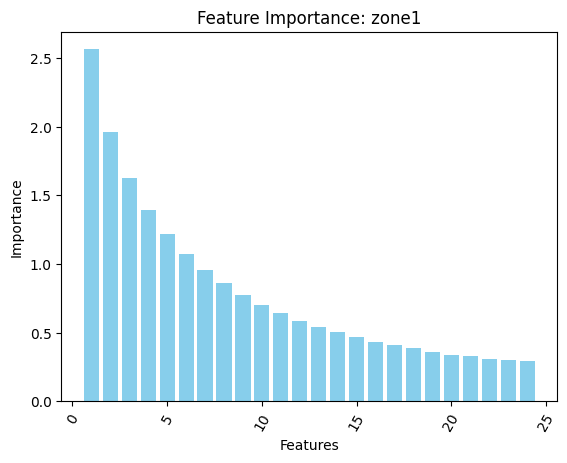

Información mutua para zone2: [0.8619746599051776, 0.8098986146446805, 0.7491671910328064, 0.6973668141092029, 0.6452816612642653, 0.6047462046686389, 0.5576117447103375, 0.5199765610724718, 0.48202134528080975, 0.44784201210896324, 0.41355993381476086, 0.3870218247039965, 0.3601562956944724, 0.3302372465237555, 0.31608102406756533, 0.2935593899166218, 0.2774865771863704, 0.2655358104106744, 0.24677759127541243, 0.22745084898595191, 0.21769752720773994, 0.19971625507054203, 0.19076910816083625, 0.1848790455139575]


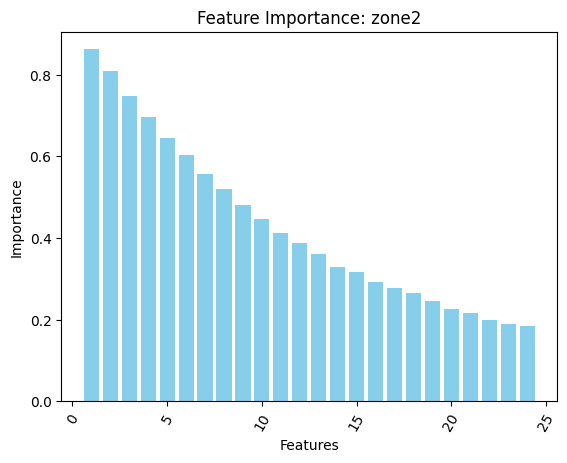

Información mutua para zone3: [0.6296971533104534, 0.5976347408188101, 0.5628684445330059, 0.5293081765758698, 0.49304248199269907, 0.46493159206127466, 0.4336546380061721, 0.41320059476102156, 0.38826708908501484, 0.3726319565549874, 0.3564475781721672, 0.34470480967375927, 0.3302976478085675, 0.318202262985392, 0.29841694058857016, 0.28967527617686883, 0.28411471307600156, 0.2659887005681689, 0.2674239349040315, 0.25019678120530653, 0.24211334920916894, 0.2372703478275744, 0.23409299867767608, 0.22621167720528312]


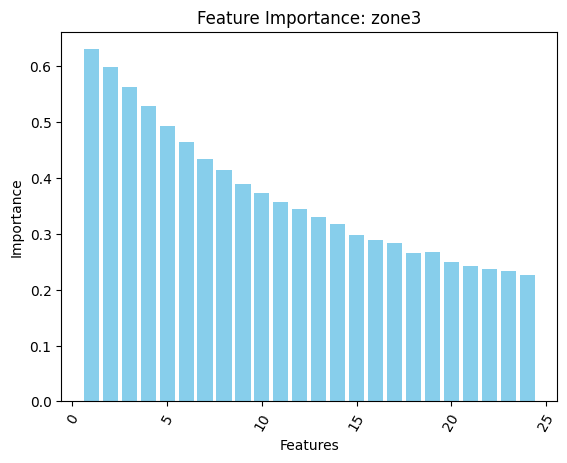

Información mutua para hour: [0.7739934467960841, 0.7676020347237795, 0.7708097574867487, 0.7714362616572341, 0.7752342172977666, 0.7747761285086234, 0.7746110543088256, 0.7676346251759054, 0.7707005150940458, 0.771279270869238, 0.7749517328874758, 0.7748486600235753, 0.7744052734438305, 0.7680155723382813, 0.7711590866261049, 0.7715431546507037, 0.7754547739372613, 0.774689063973534, 0.7744913968366327, 0.7674899407562745, 0.7703584133663304, 0.7713489386436732, 0.7749272824422087, 0.7746161784212773]


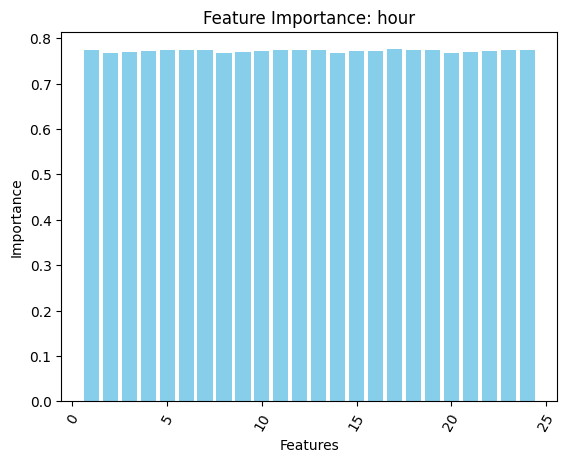

Lags óptimos encontrados para cada columna:
{'temp': 3, 'zone1': 1, 'zone2': 1, 'zone3': 1, 'hour': 17}


In [ ]:
from sklearn.feature_selection import mutual_info_regression
import numpy as np
import pandas as pd
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
np.random.seed(42)


data = final.copy()

# Agregar lags al DataFrame
num_lags = 24  # Número máximo de lags a considerar

ejeX = list(range(1, num_lags+1))


for i in range(1, num_lags + 1):
    for col in final.columns:
        data[f'{col}_lag_{i}'] = final[col].shift(i)


lag_optimos = {}

# Configurar el método para calcular la información mutua
def calculate_mutual_info(X, y):
    mi = mutual_info_regression(X, y)
    return mi

# Iterar sobre cada columna (cada serie temporal de lag)
for col in final.columns:
    mutual_infos = []
    for i in range(1, num_lags + 1):
        # Extraer la característica de lag y la serie objetivo

        data2 = data.dropna(subset=[f'{col}_lag_{i}'])

        X = data2[[f'{col}_lag_{i}']]
        y = data2['zone1']  

        # Calcular la información mutua
        mi = calculate_mutual_info(X, y)
        mutual_infos.append(mi[0])  # Guardar el valor de información mutua

    print(f"Información mutua para {col}: {mutual_infos}")

    plt.bar(ejeX, mutual_infos, color='skyblue')
    plt.title(f'Feature Importance: {col}')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=60)
    #plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    plt.show()


    # Encontrar el lag con la mayor importancia
    lag_optimo = np.argmax(mutual_infos) + 1
    lag_optimos[col] = lag_optimo

print("Lags óptimos encontrados para cada columna:")
print(lag_optimos)


# Otros análisis

Para confirmar, se imprimen las gráficas de la función de autocorrelación de cada variable. Al haber descensos consistentes y lentos, no haber convergencia en algún punto y la existencia de un componente temporal, pareciese indicar que las series probablemente no son estacionarias. De igual manera, la presencia de repetición en ciertos patrones pareciese indicar que existe estacionalidad en algunas series.

In [ ]:
def acf(name, data):
  plot_acf(data[name], lags=50)
  plt.xlabel('Lag')
  plt.ylabel('Autocorrelation')
  plt.title('Gráfico de ACF para {}'.format(name))
  plt.show()

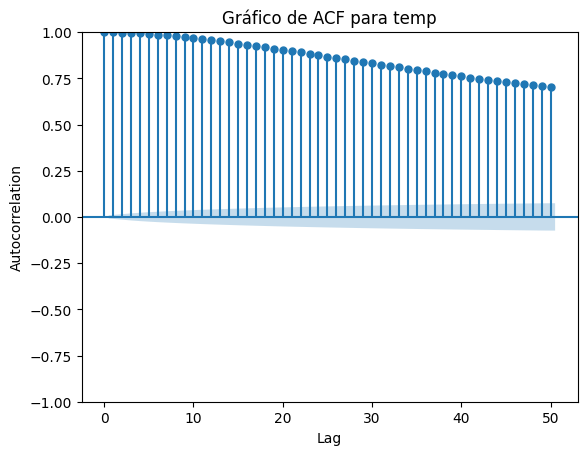

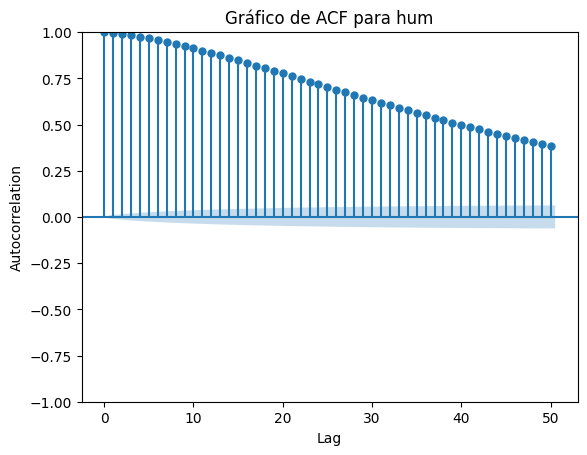

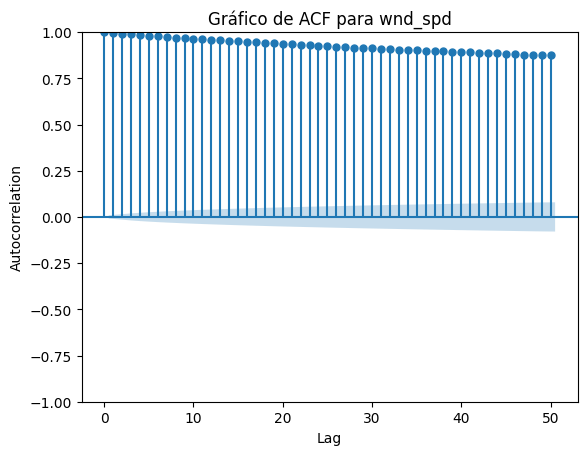

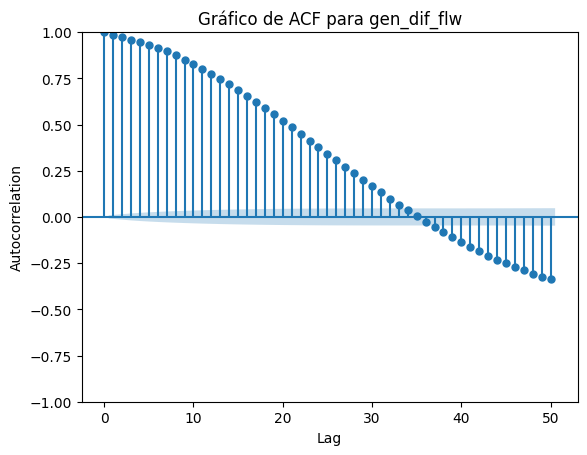

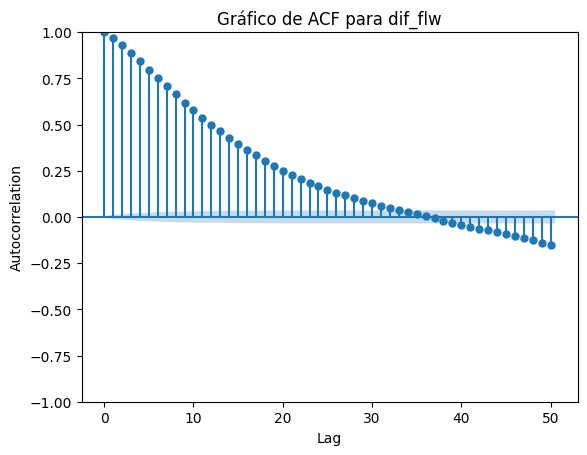

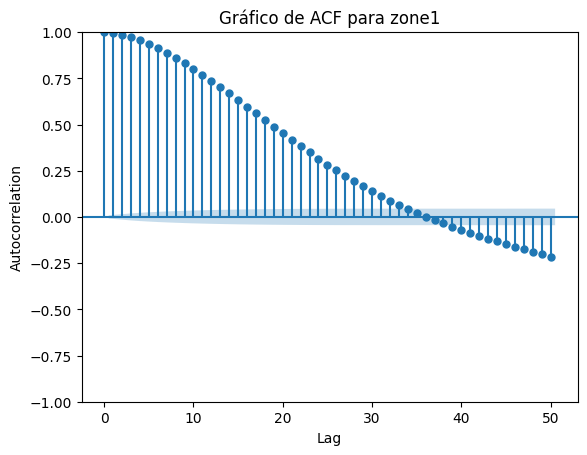

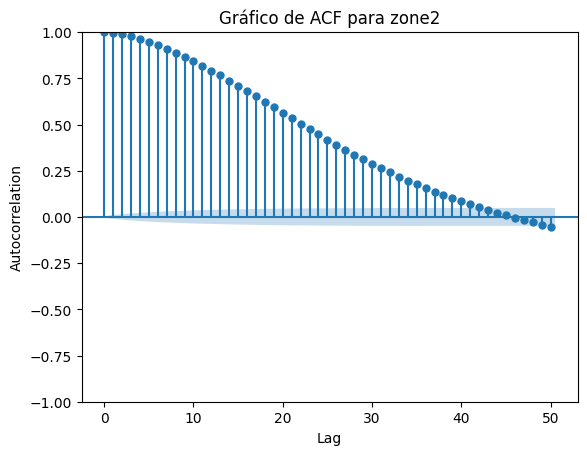

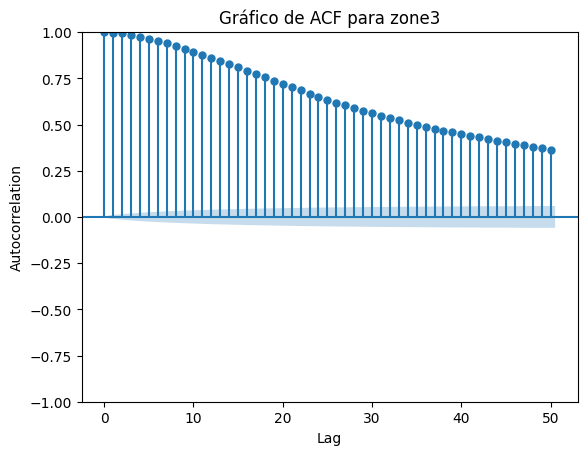

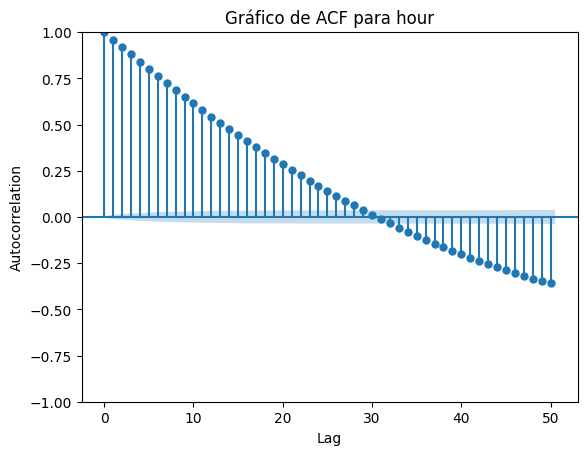

In [ ]:
for name in df:
  acf(name, df)

A modo de investigar la inconsistencia anterior, se resamplea la serie a un periodo de 1 hr, promediando los valores en sí, para así revisar si los gráficos ACF cambian.

Cada 1 Hrs

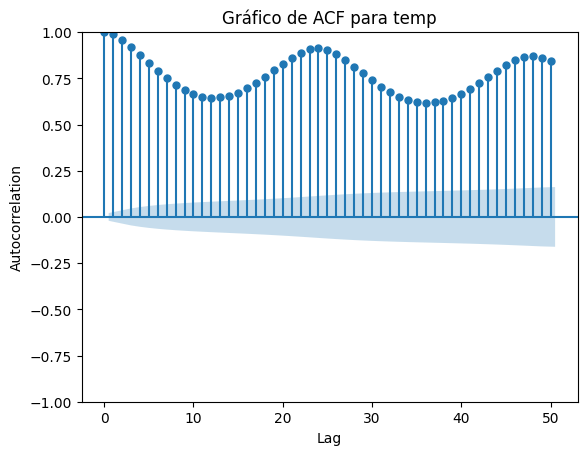

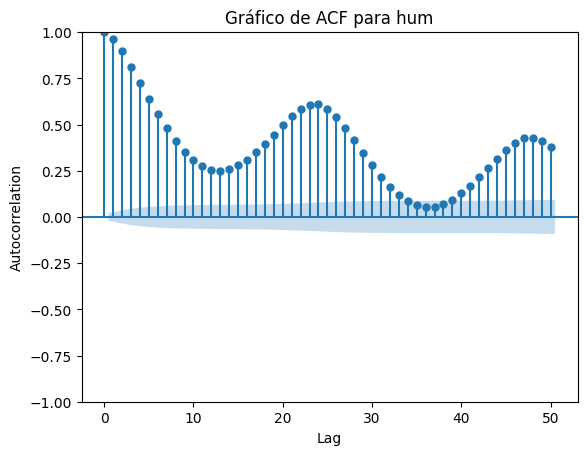

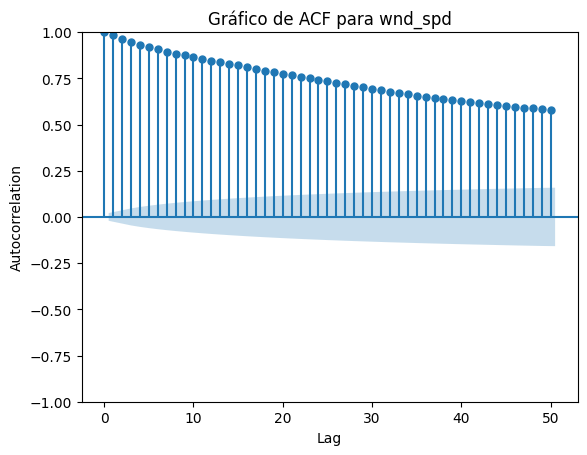

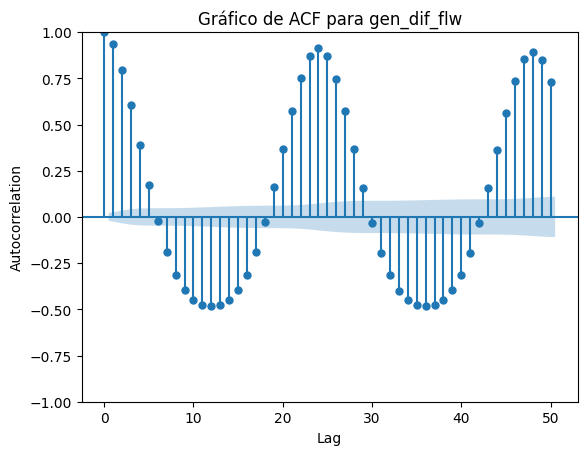

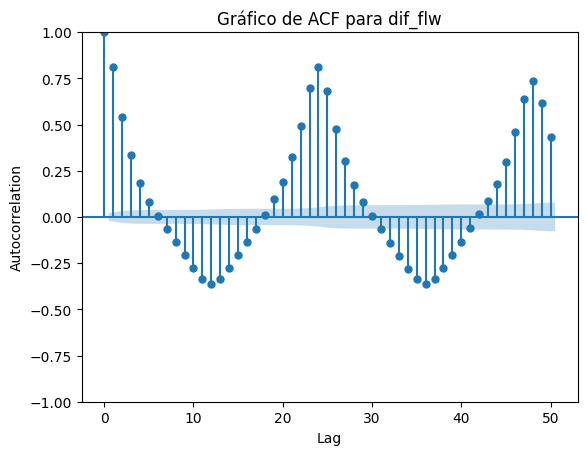

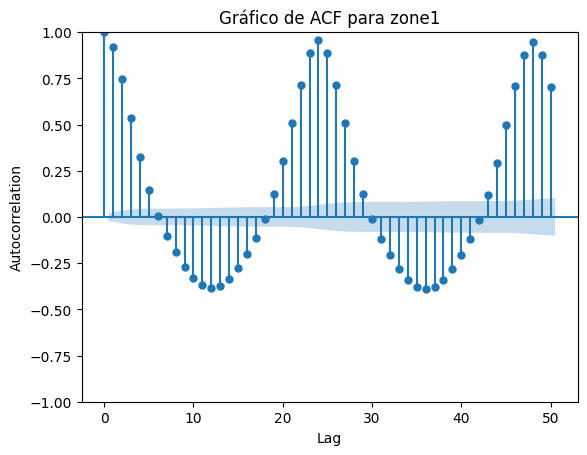

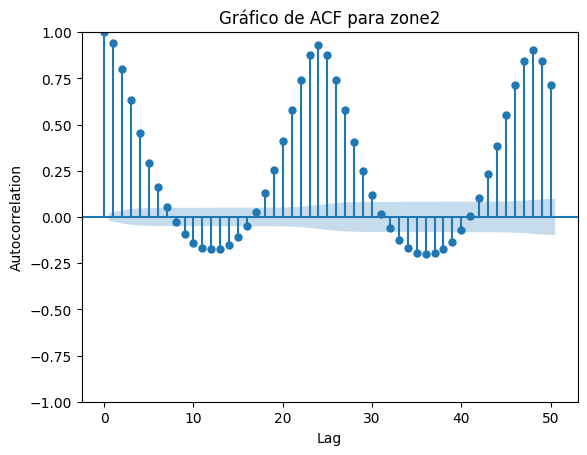

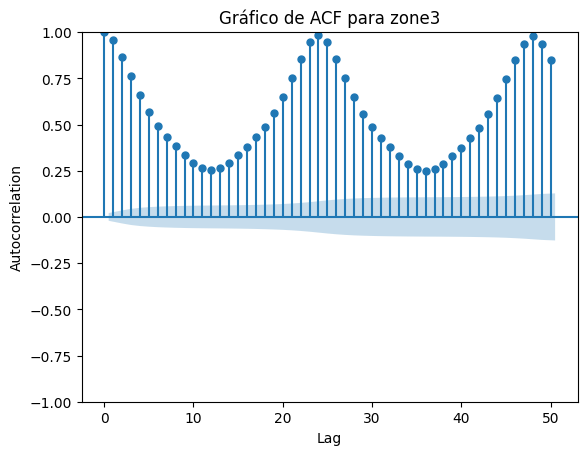

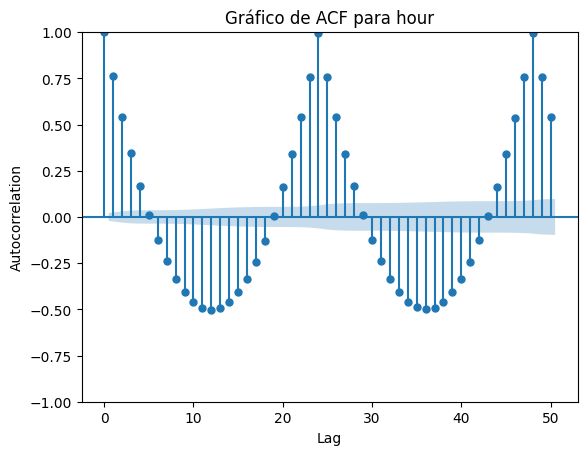

In [ ]:
data_resampled = df.resample('1H').mean()
for name in data_resampled:
  acf(name, data_resampled)

Cada 24 H

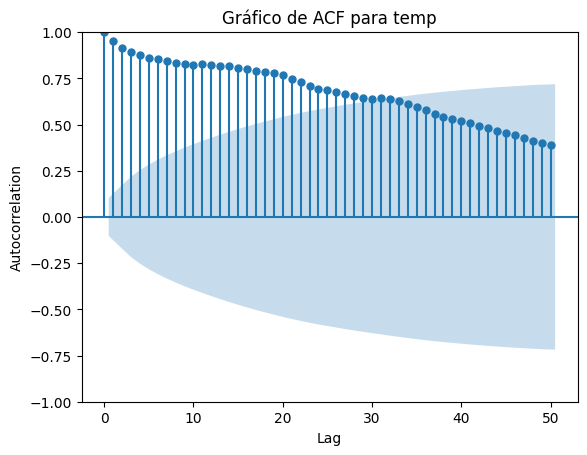

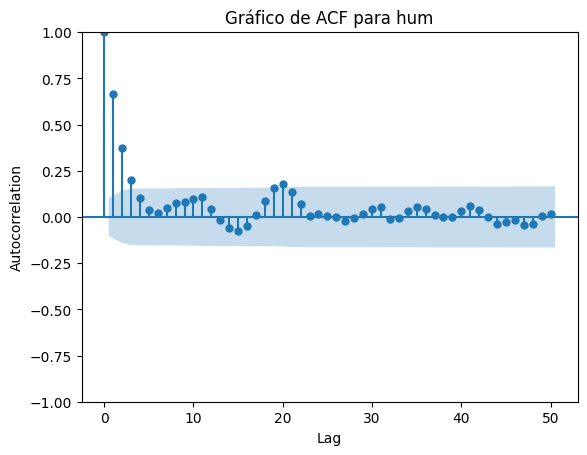

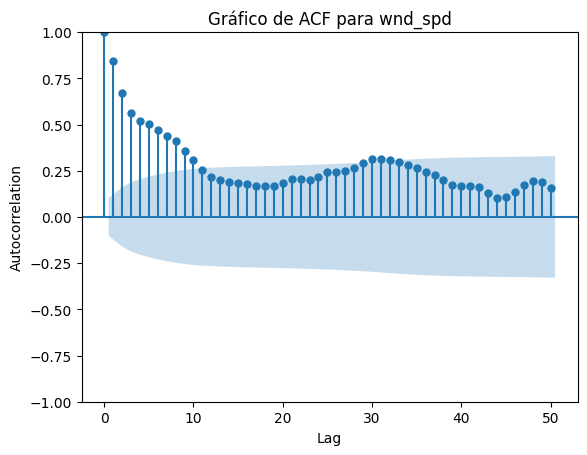

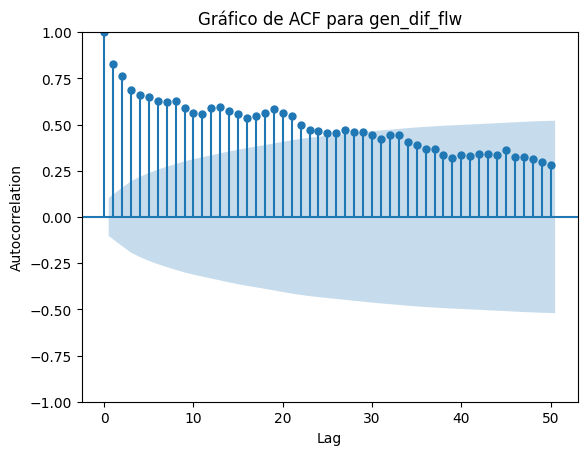

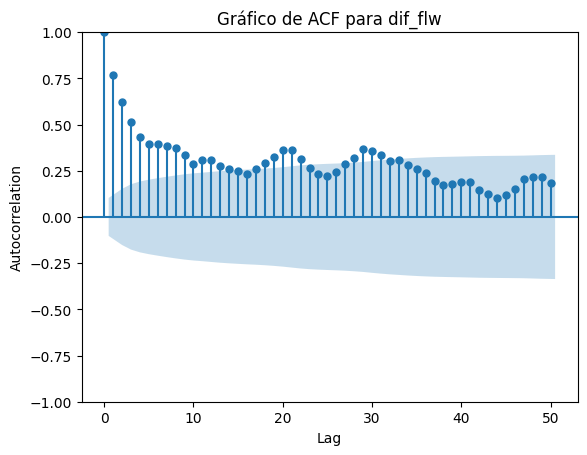

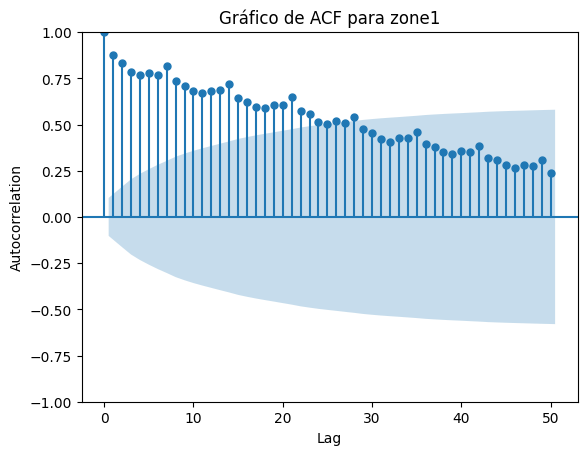

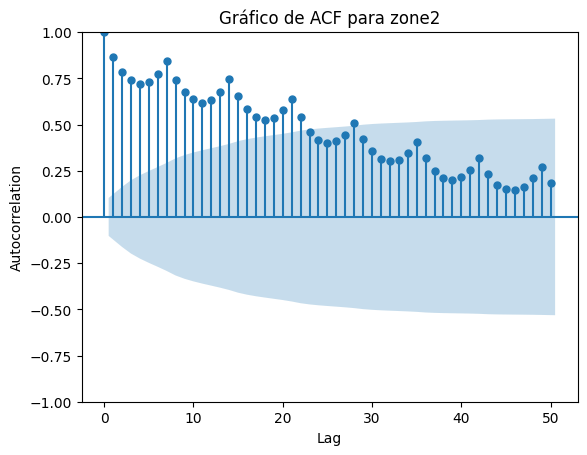

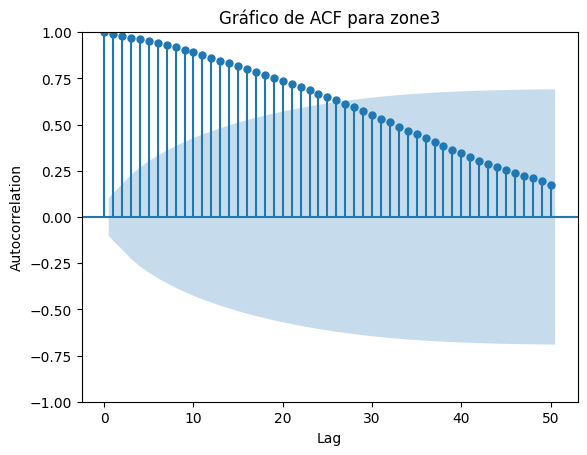

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stattools.py:693: RuntimeWarning:

divide by zero encountered in divide

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stattools.py:693: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_base.py:2503: UserWarning:




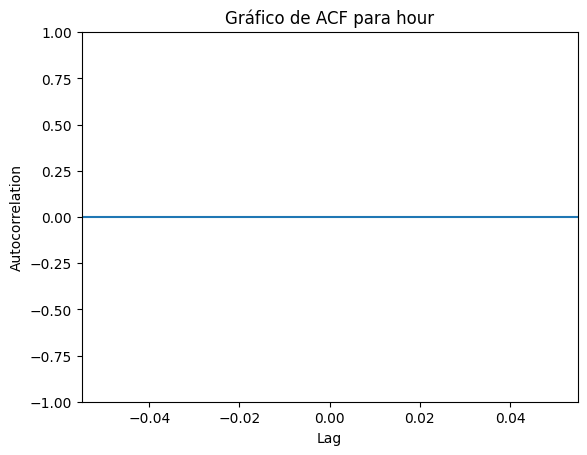

In [ ]:
data_resampled2 = df.resample('24H').mean()
for name in data_resampled2:
  acf(name, data_resampled2)

De los gráficos anteriores se puede observar que, si bien ahora el decaimiento es mucho más rápido, aún pareciesen haber componentes que indican la presencia de estacionalidad. De igual manera se ve la presencia de estacionalidad

In [ ]:
def descomponer(name, data):
  decompose = seasonal_decompose(data[name], model='additive')

  decompose.plot()
  plt.subplots_adjust(right=1.25)
  plt.show()

#decompose.seasonal["2010-01"].plot()
#plt.subplots_adjust(right=1.25)

#plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

#plt.show()



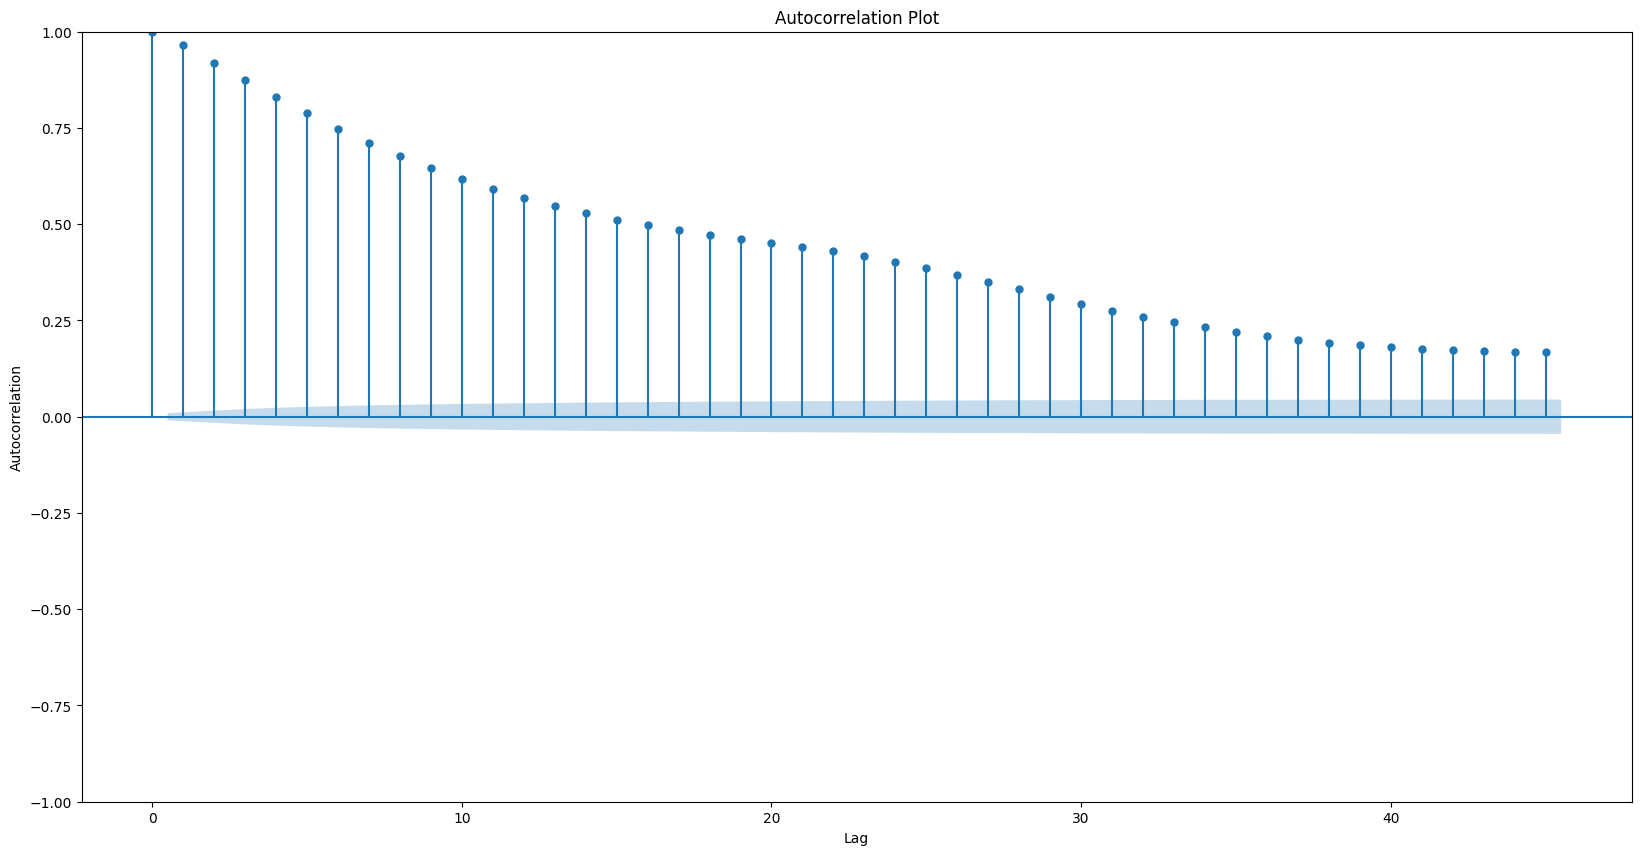

In [ ]:
data_resampled = df["pollution"].resample('H').mean()
plot_acf(data_resampled, lags= 45)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Plot')
plt.show()

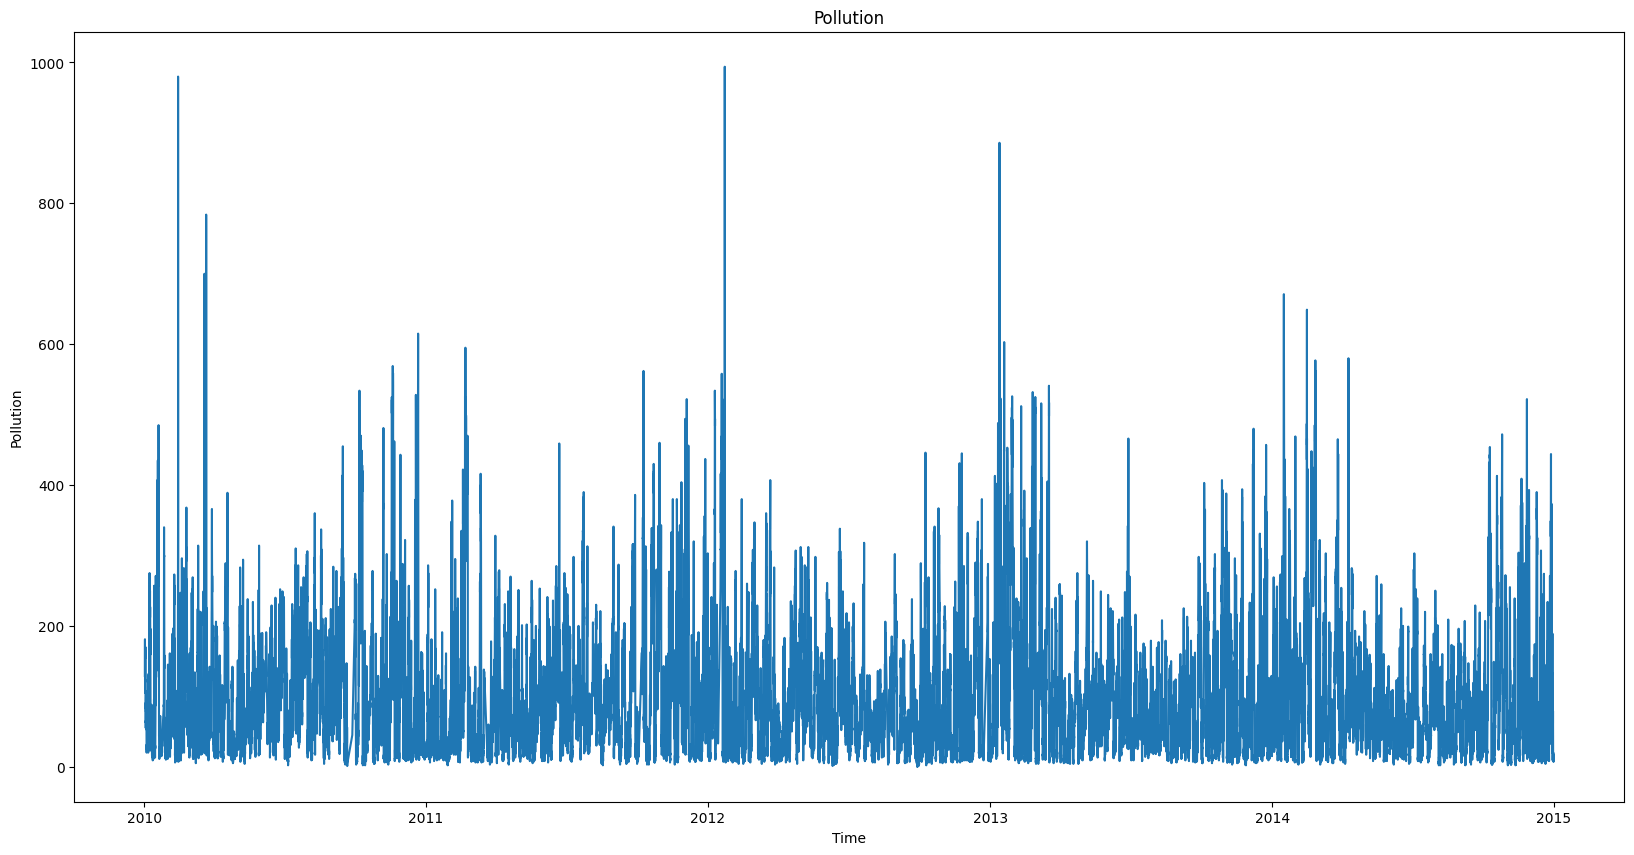

In [ ]:
# Plot the time-series data
plt.plot(data_resampled)
plt.xlabel('Time')
plt.ylabel('Pollution')
plt.title('Pollution')
plt.rcParams['figure.figsize'] = (20.0, 10.0)
plt.show()

In [ ]:
resultado_adf = adfuller(data_resampled)

# Imprimir el resultado
print('Estadística ADF:', resultado_adf[0])
print('Valor p:', resultado_adf[1])
print("Cantidad de observaciones utilizadas: ", resultado_adf[2])
print('Valores críticos:')
for key, value in resultado_adf[4].items():
    print('\t%s: %.3f' % (key, value))

Estadística ADF: -4.966090574095693
Valor p: 2.5890697771331073e-05
Cantidad de observaciones utilizadas:  10
Valores críticos:
	1%: -3.571
	5%: -2.923
	10%: -2.599


Sugiere que la serie es no estacionaria

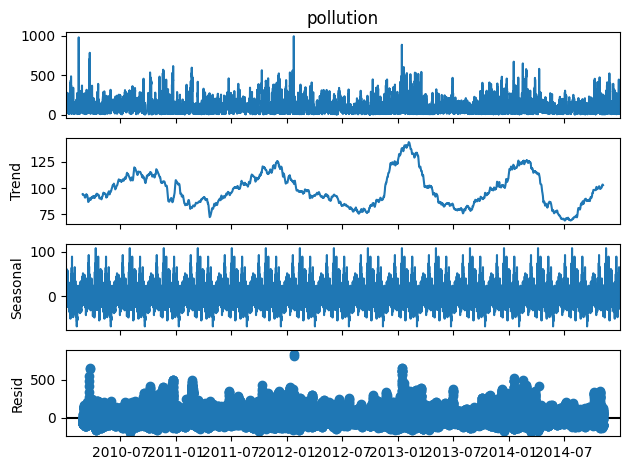

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose = seasonal_decompose(df['pollution'],model='additive', period=2688)
decompose.plot()
plt.show()




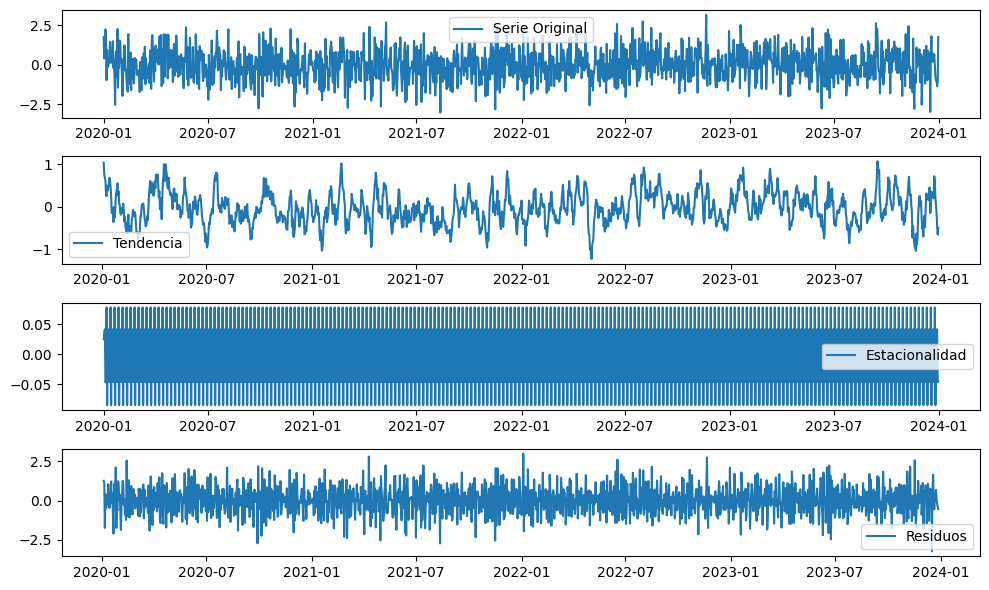

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Crear una serie de tiempo estacionaria
np.random.seed(0)
fechas = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
serie_tiempo = pd.Series(np.random.randn(len(fechas)), index=fechas)

# Descomponer la serie de tiempo
decomposition = seasonal_decompose(serie_tiempo, model='additive')

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Graficar la descomposición
plt.subplot(411)
plt.plot(serie_tiempo, label='Serie Original')
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label='Tendencia')
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuos')
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

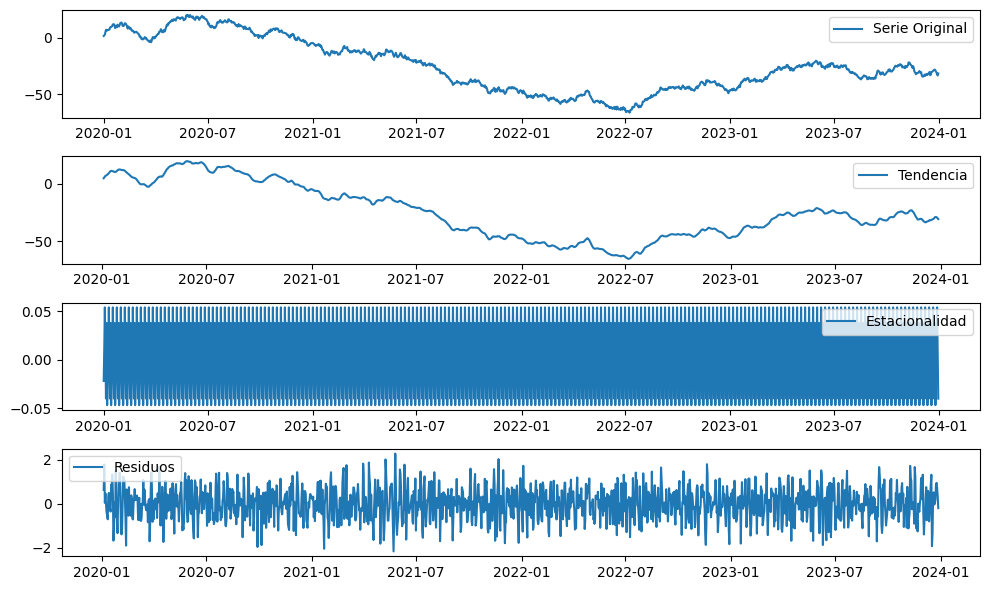

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Crear una serie de tiempo no estacionaria
np.random.seed(0)
fechas = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
serie_tiempo = pd.Series(np.cumsum(np.random.randn(len(fechas))), index=fechas)

# Descomponer la serie de tiempo
decomposition = seasonal_decompose(serie_tiempo, model='additive')

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Graficar la descomposición
plt.subplot(411)
plt.plot(serie_tiempo, label='Serie Original')
plt.legend()

plt.subplot(412)
plt.plot(decomposition.trend, label='Tendencia')
plt.legend()

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuos')
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()